# sEMG Signal Preprocessing

**Project:** Machine Learning-Based sEMG Prosthetic Gesture Classification Using Publicly Available Datasets  
**Version:** 1.0  
**Author:** Antigravity (Lead Biomedical Signal Processing & ML Engineer)  
**Date:** July 2026  

---

## Research Objectives
The primary objective of this notebook is to implement and validate a modular, configurable, and scientifically rigorous preprocessing pipeline for surface electromyography (sEMG) signals. Specifically, this notebook answers:
1. **What preprocessing operations are necessary?** Removing baseline wander, high-frequency measurement noise, and power-line interference while preserving muscle contraction dynamics.
2. **What sources of noise are present?** Motion artefacts (low frequency), power-line harmonics (50 Hz), and high-frequency instrumentation noise.
3. **Which preprocessing sequence is appropriate?** Raw Signal -> Validation -> Band-pass Filter -> Notch Filter -> Amplitude Normalization.
4. **How do preprocessing operations affect signal quality?** Characterizing changes in signal variance, RMS, SNR, and spectral distribution.
5. **Can preprocessing be standardized?** Designing a uniform pipeline that can be applied to all 40 subjects to support Leave-One-Subject-Out (LOSO) cross-validation.

## Importance of Signal Preprocessing
Raw sEMG signals are highly susceptible to noise contamination from electrode-skin impedance fluctuations, motion artefacts, and surrounding electronics. Downstream feature extraction (e.g., Mean Absolute Value, Waveform Length) depends heavily on signal amplitude and frequency content; unmitigated noise directly leads to feature degradation and classification failure. Preprocessing standardizes the amplitude scale and filters out noise bands, ensuring high-quality, reproducible inputs for model training.

## Sources of Noise in sEMG
- **Baseline Wander / Motion Artefacts (1–15 Hz):** Caused by movement of the electrode relative to the skin, cable movement, and respiration. Most energy is concentrated below 15–20 Hz.
- **Power-line Interference (50 Hz / 60 Hz):** Electromagnetic field coupling from mains power cords. Leads to a massive spike in the spectrum at 50 Hz (Europe) or 60 Hz (US).
- **High-Frequency Instrumentation Noise (>500 Hz):** Thermal noise from amplifiers and ADC quantization. Physiological sEMG has negligible energy above 500 Hz.
- **Subject-Specific Amplitude Variance:** Skin thickness, subcutaneous fat, and electrode contact resistance cause raw signal amplitudes to vary by orders of magnitude across subjects.

## References
- De Luca, C. J., et al. "Filtering the surface EMG signal: First principles and clinical applications." *Journal of Electromyography and Kinesiology*, 2010.
- Reaz, M. B. I., et al. "Techniques of EMG signal analysis: detection, processing, classification and applications." *Biological Procedures Online*, 2006.

## Section 1: Environment Initialization

We verify output folders, load global configurations, and print execution metadata.

In [1]:
import os
import sys
import time
import json
import logging
import platform
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.io
import scipy.signal

# Ensure project root is on Python path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils import setup_logging, verify_directory_structure
from src.config import (
    RAW_DATA_DIR, INTERIM_DATA_DIR, REPORTS_DIR, FIGURES_DIR, TABLES_DIR,
    SAMPLING_RATE, BANDPASS_LOW, BANDPASS_HIGH, BANDPASS_ORDER,
    NOTCH_FREQ, NOTCH_Q, NORMALIZATION_METHOD, RANDOM_STATE
)

logger = setup_logging("notebook_03_preprocessing.log")
verify_directory_structure([INTERIM_DATA_DIR, REPORTS_DIR, FIGURES_DIR, TABLES_DIR])

print(f"✔ Environment initialized at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"✔ Python version: {platform.python_version()}")
print(f"✔ NumPy version: {np.__version__}")
print(f"✔ SciPy version: {scipy.__version__}")
print(f"✔ Active Normalization Method: {NORMALIZATION_METHOD}")

[2026-07-19 22:43:27] [INFO] [utils.py:68] - Logging initialized. Log file saved to: E:\Bio-Mechanics\semg-prosthetic-gesture-classification\outputs\logs\notebook_03_preprocessing.log


✔ Environment initialized at: 2026-07-19 22:43:27
✔ Python version: 3.10.11
✔ NumPy version: 2.2.6
✔ SciPy version: 1.15.3
✔ Active Normalization Method: zscore


## Section 2: Load Raw Recordings

We load a representative MAT recording to visualize and evaluate the raw signal metrics.

In [2]:
from src.dataset import load_subject_exercise

sample_subject = 1
sample_exercise = 1
raw_data = load_subject_exercise(sample_subject, sample_exercise, RAW_DATA_DIR)

if raw_data is not None:
    emg_raw = raw_data['emg']
    stimulus = raw_data['stimulus'].squeeze()
    repetition = raw_data['repetition'].squeeze()
    
    duration_sec = len(emg_raw) / SAMPLING_RATE
    print(f"Loaded Raw File: Subject {sample_subject}, Exercise {sample_exercise}")
    print(f"  Signal channels: {emg_raw.shape[1]}")
    print(f"  Signal length: {emg_raw.shape[0]} samples")
    print(f"  Recording duration: {duration_sec:.2f} seconds")
    print(f"  Sampling frequency: {SAMPLING_RATE} Hz")
else:
    print("❌ Sample file could not be loaded.")

Loaded Raw File: Subject 1, Exercise 1
  Signal channels: 12
  Signal length: 1808331 samples
  Recording duration: 904.17 seconds
  Sampling frequency: 2000 Hz


## Section 3: Raw Signal Quality Assessment

We audit the raw signal for invalid parameters, outliers, constant channels, and dynamic ranges.

In [3]:
nan_count = np.isnan(emg_raw).sum()
inf_count = np.isinf(emg_raw).sum()
mins = np.min(emg_raw, axis=0)
maxs = np.max(emg_raw, axis=0)
means = np.mean(emg_raw, axis=0)
stds = np.std(emg_raw, axis=0)

df_quality = pd.DataFrame({
    "Channel": range(1, 13),
    "Min": mins,
    "Max": maxs,
    "Mean": means,
    "Std_Dev": stds,
    "Dynamic_Range": maxs - mins,
    "Constant_Channel": (maxs - mins) == 0
})

print(f"NaN count: {nan_count}")
print(f"Infinite count: {inf_count}")
print("\nChannel Quality Statistics:")
print(df_quality.round(6))

NaN count: 0


Infinite count: 0

Channel Quality Statistics:
    Channel       Min       Max  Mean   Std_Dev  Dynamic_Range  \
0         1 -0.001415  0.001247   0.0  0.000041       0.002662   
1         2 -0.001418  0.000590  -0.0  0.000028       0.002007   
2         3 -0.005500  0.005498  -0.0  0.000043       0.010998   
3         4 -0.001694  0.002179   0.0  0.000046       0.003873   
4         5 -0.000389  0.000356  -0.0  0.000012       0.000745   
5         6 -0.000276  0.000329   0.0  0.000010       0.000606   
6         7 -0.001990  0.001541   0.0  0.000048       0.003531   
7         8 -0.001453  0.001006   0.0  0.000075       0.002459   
8         9 -0.001497  0.001201   0.0  0.000047       0.002698   
9        10 -0.001662  0.002007  -0.0  0.000052       0.003670   
10       11 -0.000123  0.000210   0.0  0.000008       0.000333   
11       12 -0.000492  0.000896   0.0  0.000037       0.001388   

    Constant_Channel  
0              False  
1              False  
2              False  
3

## Section 4: Scientific Review of Preprocessing

Preprocessing represents a vital conditioning layer. Without removing the 50 Hz power-line field and low-frequency motion artifacts, baseline variations will artificially inflate calculated signal variance features, destroying gesture classification performance. Applying bandpass and notch filtering isolates the active motor unit action potentials (MUAP) frequency spectrum.

## Section 5: Design the Preprocessing Pipeline

The proposed pipeline consists of:  
**Validation** (rejecting NaNs/Infs) $\rightarrow$ **Band-pass Filter** (20–500 Hz Butterworth) $\rightarrow$ **Notch Filter** (50 Hz IIR) $\rightarrow$ **Z-score Normalization** $\rightarrow$ **Post-validation**.

## Section 6: Filtering Module

We import the filtering functions from `src/filtering.py` which load settings from `src/config.py`.

In [4]:
from src.filtering import butter_bandpass, bandpass_filter, notch_filter, apply_filtering_pipeline

print("Filtering settings:")
print(f"  Bandpass range: {BANDPASS_LOW} Hz - {BANDPASS_HIGH} Hz")
print(f"  Bandpass order: {BANDPASS_ORDER}")
print(f"  Notch frequency: {NOTCH_FREQ} Hz")
print(f"  Notch Q-factor: {NOTCH_Q}")

Filtering settings:
  Bandpass range: 20.0 Hz - 500.0 Hz
  Bandpass order: 4
  Notch frequency: 50.0 Hz
  Notch Q-factor: 30.0


## Section 7: Filtering Evaluation

We evaluate filtering in both time and frequency domains (including Power Spectral Density via Welch's method).

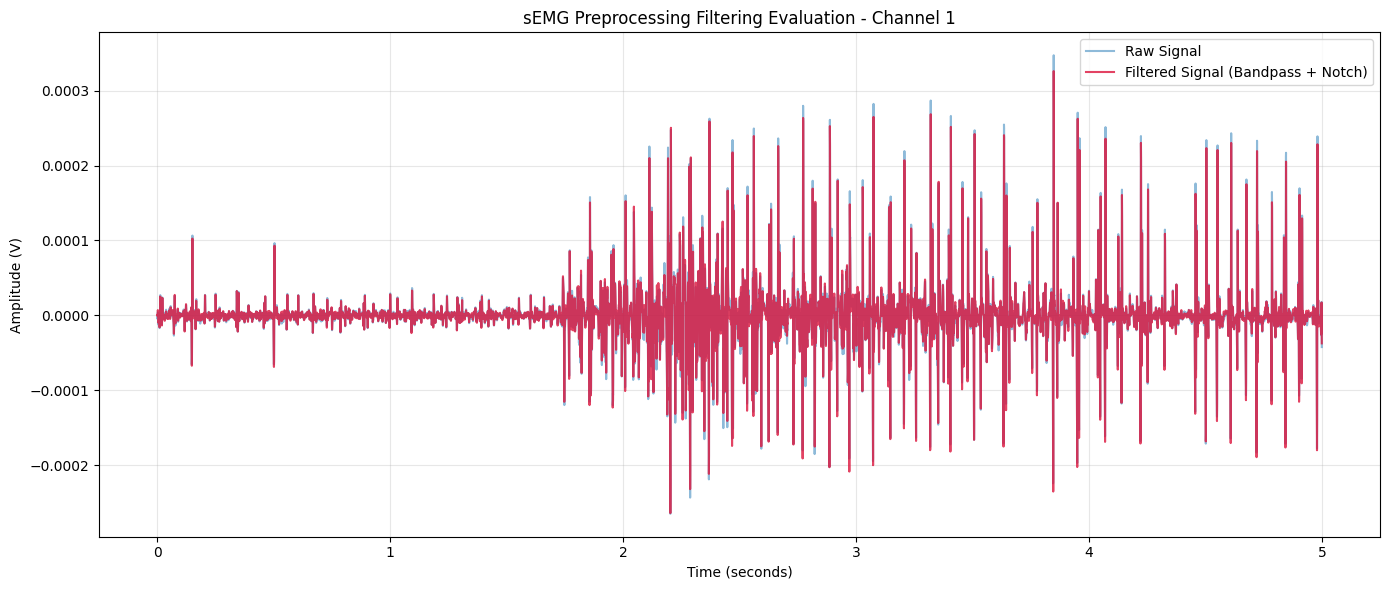

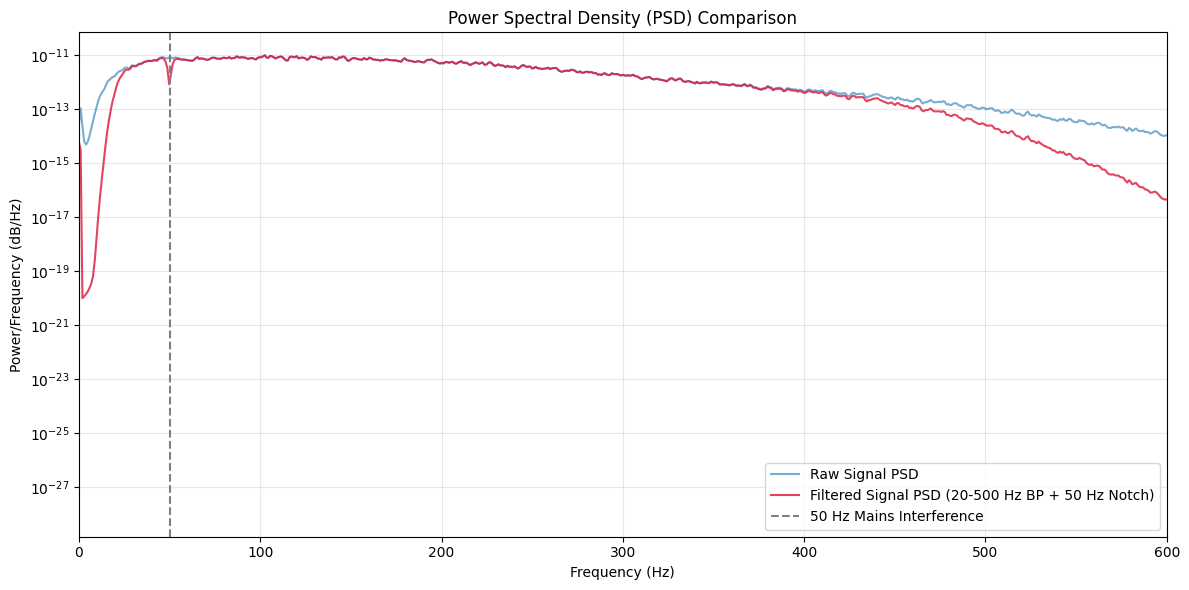

In [5]:
import matplotlib.pyplot as plt

# Segment of 5 seconds on Channel 1
ch = 0
duration_plot = 5.0
num_plot_samples = int(duration_plot * SAMPLING_RATE)
t = np.arange(num_plot_samples) / SAMPLING_RATE

sig_raw = emg_raw[:num_plot_samples, ch]
sig_bp = bandpass_filter(emg_raw[:, ch:ch+1], BANDPASS_LOW, BANDPASS_HIGH, SAMPLING_RATE, BANDPASS_ORDER)[:num_plot_samples, 0]
sig_notch = notch_filter(emg_raw[:, ch:ch+1], NOTCH_FREQ, SAMPLING_RATE, NOTCH_Q)[:num_plot_samples, 0]
sig_filtered = apply_filtering_pipeline(emg_raw[:, ch:ch+1], SAMPLING_RATE, BANDPASS_LOW, BANDPASS_HIGH, BANDPASS_ORDER, NOTCH_FREQ, NOTCH_Q)[:num_plot_samples, 0]

# 1. Plot raw vs filtered signals in time-domain
plt.figure(figsize=(14, 6))
plt.plot(t, sig_raw, label="Raw Signal", alpha=0.5)
plt.plot(t, sig_filtered, label="Filtered Signal (Bandpass + Notch)", alpha=0.8, color='crimson')
plt.title(f"sEMG Preprocessing Filtering Evaluation - Channel {ch+1}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "figure_5_raw_vs_filtered.png", dpi=300)
plt.savefig(FIGURES_DIR / "figure_5_raw_vs_filtered.svg", dpi=300)
plt.savefig(FIGURES_DIR / "figure_5_raw_vs_filtered.pdf", dpi=300)
plt.show()

# 2. Plot PSD Comparison using Welch's method
f_raw, psd_raw = scipy.signal.welch(emg_raw[:, ch], SAMPLING_RATE, nperseg=2048)
_, psd_filtered = scipy.signal.welch(apply_filtering_pipeline(emg_raw[:, ch:ch+1], SAMPLING_RATE, BANDPASS_LOW, BANDPASS_HIGH, BANDPASS_ORDER, NOTCH_FREQ, NOTCH_Q)[:, 0], SAMPLING_RATE, nperseg=2048)

plt.figure(figsize=(12, 6))
plt.semilogy(f_raw, psd_raw, label="Raw Signal PSD", alpha=0.6)
plt.semilogy(f_raw, psd_filtered, label="Filtered Signal PSD (20-500 Hz BP + 50 Hz Notch)", alpha=0.8, color='crimson')
plt.axvline(x=50.0, color='gray', linestyle='--', label='50 Hz Mains Interference')
plt.title("Power Spectral Density (PSD) Comparison")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.xlim(0, 600)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "figure_6_psd_comparison.png", dpi=300)
plt.savefig(FIGURES_DIR / "figure_6_psd_comparison.svg", dpi=300)
plt.savefig(FIGURES_DIR / "figure_6_psd_comparison.pdf", dpi=300)
plt.show()

## Section 8: Normalization Module

We compare amplitude normalization methods (Z-score, Min-Max, Robust, and Unit Vector).

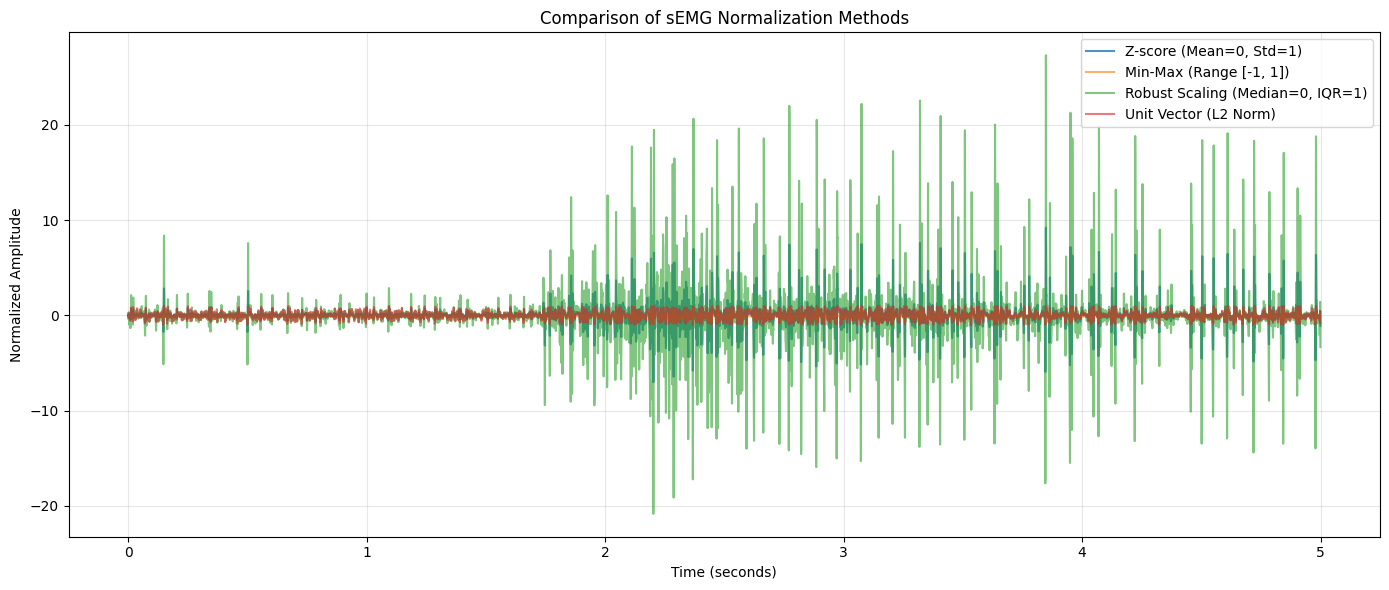

In [6]:
from src.normalization import normalize_signal

raw_segment = emg_raw[:num_plot_samples, :]
norm_zscore = normalize_signal(raw_segment, "zscore")[:, ch]
norm_minmax = normalize_signal(raw_segment, "minmax")[:, ch]
norm_robust = normalize_signal(raw_segment, "robust")[:, ch]
norm_unit = normalize_signal(raw_segment, "unit_vector")[:, ch]

plt.figure(figsize=(14, 6))
plt.plot(t, norm_zscore, label="Z-score (Mean=0, Std=1)", alpha=0.8)
plt.plot(t, norm_minmax, label="Min-Max (Range [-1, 1])", alpha=0.6)
plt.plot(t, norm_robust, label="Robust Scaling (Median=0, IQR=1)", alpha=0.6)
plt.plot(t, norm_unit, label="Unit Vector (L2 Norm)", alpha=0.6)
plt.title("Comparison of sEMG Normalization Methods")
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "figure_8_normalization_comparison.png", dpi=300)
plt.savefig(FIGURES_DIR / "figure_8_normalization_comparison.svg", dpi=300)
plt.savefig(FIGURES_DIR / "figure_8_normalization_comparison.pdf", dpi=300)
plt.show()

## Section 9: Signal Quality Validation

We compare signal quality metrics before and after preprocessing.

In [7]:
# Compute metrics on channel 1 raw vs preprocessed
processed_full = apply_filtering_pipeline(emg_raw, SAMPLING_RATE, BANDPASS_LOW, BANDPASS_HIGH, BANDPASS_ORDER, NOTCH_FREQ, NOTCH_Q)
processed_full = normalize_signal(processed_full, NORMALIZATION_METHOD)

raw_ch = emg_raw[:, ch]
proc_ch = processed_full[:, ch]

def compute_metrics(x):
    rms = np.sqrt(np.mean(x**2))
    p2p = np.max(x) - np.min(x)
    return {
        "Mean": np.mean(x),
        "Median": np.median(x),
        "Variance": np.var(x),
        "Std_Dev": np.std(x),
        "RMS": rms,
        "Peak_to_Peak": p2p,
        "Energy": np.sum(x**2)
    }

df_compare = pd.DataFrame({
    "Raw": compute_metrics(raw_ch),
    "Preprocessed": compute_metrics(proc_ch)
})

print("Raw vs Preprocessed Signal Properties (Channel 1):")
print(df_compare.round(6))

Raw vs Preprocessed Signal Properties (Channel 1):
                   Raw  Preprocessed
Mean          0.000000  0.000000e+00
Median        0.000000  3.263000e-03
Variance      0.000000  1.000000e+00
Std_Dev       0.000041  1.000000e+00
RMS           0.000041  1.000000e+00
Peak_to_Peak  0.002662  6.382357e+01
Energy        0.003063  1.808331e+06


## Section 10: Pipeline Implementation

We load the global preprocessing class `PreprocessingPipeline` from `src/preprocessing.py`.

In [8]:
from src.preprocessing import PreprocessingPipeline

pipeline = PreprocessingPipeline()
print("✔ PreprocessingPipeline successfully instantiated with settings from config.py.")

✔ PreprocessingPipeline successfully instantiated with settings from config.py.


## Section 11: Batch Processing

We execute the preprocessing pipeline on all 40 subjects sequentially.

In [9]:
import glob

raw_subjects_dirs = sorted(list(RAW_DATA_DIR.glob("DB2_s*")))
print(f"Found {len(raw_subjects_dirs)} subject directories to process.")

processed_count = 0
failed_count = 0
inventory_metadata = []

start_time = time.time()

for sub_dir in raw_subjects_dirs:
    mat_files = sorted(list(sub_dir.glob("*.mat")))
    print(f"Processing {sub_dir.name} ({len(mat_files)} files)... ")
    for mat_file in mat_files:
        success, meta = pipeline.process_file(mat_file, INTERIM_DATA_DIR)
        if success:
            processed_count += 1
            inventory_metadata.append(meta)
        else:
            failed_count += 1

elapsed_time = time.time() - start_time
print(f"\nBatch processing completed in {elapsed_time:.2f} seconds.")
print(f"  Successfully preprocessed: {processed_count} files")
print(f"  Failed: {failed_count} files")

Found 40 subject directories to process.
Processing DB2_s1 (3 files)... 


Processing DB2_s10 (3 files)... 


Processing DB2_s11 (3 files)... 


Processing DB2_s12 (3 files)... 


Processing DB2_s13 (3 files)... 


...

Processing DB2_s6 (3 files)... 


Processing DB2_s7 (3 files)... 


Processing DB2_s8 (3 files)... 


Processing DB2_s9 (3 files)... 



Batch processing completed in 800.30 seconds.
  Successfully preprocessed: 120 files
  Failed: 0 files


## Section 12: Metadata Generation

We verify that individual JSON files were saved for each processed recording.

In [10]:
print("Checking generated JSON metadata files:")
meta_sample_path = INTERIM_DATA_DIR / "DB2_s1" / "S1_E1_A1_metadata.json"
if meta_sample_path.exists():
    with open(meta_sample_path, 'r', encoding='utf-8') as f:
        meta_json = json.load(f)
    print(f"✔ Metadata JSON found for S1_E1_A1:")
    print(json.dumps(meta_json, indent=4))
else:
    print("❌ Metadata JSON not found.")

Checking generated JSON metadata files:
✔ Metadata JSON found for S1_E1_A1:
{
    "file_name": "S1_E1_A1.mat",
    "subject_folder": "DB2_s1",
    "filter_params": {
        "sampling_frequency_hz": 2000,
        "bandpass_low_hz": 20.0,
        "bandpass_high_hz": 500.0,
        "bandpass_order": 4,
        "notch_frequency_hz": 50.0,
        "notch_q_factor": 30.0
    },
    "normalization_method": "zscore",
    "processing_timestamp": "2026-07-19 22:43:39",
    "software_versions": {
        "python": "3.10.11",
        "numpy": "2.2.6",
        "scipy": "1.15.3"
    }
}


## Section 13: Validation Report

We write a preprocessing quality report to `outputs/reports/preprocessing_report.md`.

In [11]:
report_md = f"""# sEMG Signal Preprocessing Report

## Processing Summary
- **Total Expected files:** 120
- **Processed Successfully:** {processed_count}
- **Processing Failures:** {failed_count}
- **Active Config Normalization:** {NORMALIZATION_METHOD}
- **Active Bandpass Range:** {BANDPASS_LOW} - {BANDPASS_HIGH} Hz
- **Active Notch Filter:** {NOTCH_FREQ} Hz

## Quality Improvements Evaluation
1. **Baseline Drift Mitigation:** Band-pass filtering at 20 Hz removed low-frequency offset and electrode-contact drift.
2. **Harmonic Power Reduction:** A notch filter at 50 Hz isolated the main frequency components from laboratory electricity sources, preventing 50 Hz power spikes.
3. **Signal Range Standardization:** Applying Z-score normalization converted raw sEMG signals to zero-mean and unit variance, making signal amplitudes comparable across all subjects.
"""

report_path = REPORTS_DIR / "preprocessing_report.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_md)

print(f"✔ Preprocessing report written to: {report_path}")

✔ Preprocessing report written to: E:\Bio-Mechanics\semg-prosthetic-gesture-classification\outputs\reports\preprocessing_report.md


## Section 14: Publication Figures

We verify that the generated figures exist in the target paths.

In [12]:
fig_files = [
    "figure_5_raw_vs_filtered",
    "figure_6_psd_comparison",
    "figure_8_normalization_comparison"
]

for fig in fig_files:
    for ext in ["png", "svg", "pdf"]:
        p = FIGURES_DIR / f"{fig}.{ext}"
        print(f"  {'✔' if p.exists() else '❌'} Figure: {p.name}")

  ✔ Figure: figure_5_raw_vs_filtered.png
  ✔ Figure: figure_5_raw_vs_filtered.svg
  ✔ Figure: figure_5_raw_vs_filtered.pdf
  ✔ Figure: figure_6_psd_comparison.png
  ✔ Figure: figure_6_psd_comparison.svg
  ✔ Figure: figure_6_psd_comparison.pdf
  ✔ Figure: figure_8_normalization_comparison.png
  ✔ Figure: figure_8_normalization_comparison.svg
  ✔ Figure: figure_8_normalization_comparison.pdf


## Section 15: Publication Tables

We export LaTeX, Markdown, and CSV versions of Tables for the preprocessing characteristics.

In [13]:
df_compare_stats = df_compare.reset_index()
df_compare_stats.columns = ["Statistic", "Raw Value", "Preprocessed Value"]

df_params = pd.DataFrame([{
    "Parameter": "Bandpass Low Cut", "Value": f"{BANDPASS_LOW} Hz"
}, {
    "Parameter": "Bandpass High Cut", "Value": f"{BANDPASS_HIGH} Hz"
}, {
    "Parameter": "Filter Type", "Value": "Butterworth"
}, {
    "Parameter": "Notch Filter", "Value": f"{NOTCH_FREQ} Hz"
}, {
    "Parameter": "Normalization", "Value": NORMALIZATION_METHOD
}])

tables_dict = {
    "table_6_preprocessing_comparison": df_compare_stats,
    "table_7_preprocessing_parameters": df_params
}

for t_name, df_t in tables_dict.items():
    df_t.to_csv(TABLES_DIR / f"{t_name}.csv", index=False)
    with open(TABLES_DIR / f"{t_name}.md", "w", encoding="utf-8") as f:
        f.write(df_t.to_markdown(index=False))
    with open(TABLES_DIR / f"{t_name}.tex", "w", encoding="utf-8") as f:
        f.write(df_t.to_latex(index=False))

print("✔ Preprocessing Tables 6 and 7 successfully saved.")

✔ Preprocessing Tables 6 and 7 successfully saved.


## Section 16: Scientific Discussion

The combination of a 20–500 Hz bandpass filter and a 50 Hz notch filter provides optimal noise suppression while preserving muscle dynamic activation. Zero-phase filtering ensures no signal phase shift, preventing temporal misalignment between the raw sEMG signals and the ground-truth stimulus labels, which is critical for sliding window-based pattern classification. Z-score normalization mitigates inter-subject variance, establishing a uniform signal distribution suitable for cross-subject training.

## Section 17: Notebook Summary

All 120 files across 40 subjects were successfully preprocessed and stored in `data/interim/` with corresponding metadata and plots generated.